I'd like to thank the author of the notebook "Tensorflow- Deep Learning to Solve Titanic", from which this code is adapted.

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print(tf.__version__)

2.1.0


In [2]:
# load data
train_data = pd.read_csv(r"../input/titanic/train.csv")
test_data = pd.read_csv(r"../input/titanic/test.csv")

In [3]:
train_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [4]:
test_data

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [5]:
# Feature Engineering

from sklearn.impute import SimpleImputer

def nan_padding(data, columns):
    for column in columns:
        imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
        data[column]=imputer.fit_transform(data[column].values.reshape(-1,1))
    return data


nan_columns = ["Age", "SibSp", "Parch"]

train_data = nan_padding(train_data, nan_columns)
test_data = nan_padding(test_data, nan_columns)

In [6]:
train_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1.0,0.0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1.0,0.0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0.0,0.0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1.0,0.0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0.0,0.0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0.0,0.0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0.0,0.0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1.0,2.0,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0.0,0.0,111369,30.0000,C148,C


In [7]:
#save PassengerId for evaluation
test_passenger_id=test_data["PassengerId"]

In [8]:
def drop_not_concerned(data, columns):
    return data.drop(columns, axis=1)

not_concerned_columns = ["PassengerId","Name", "Ticket", "Fare", "Cabin", "Embarked"]
train_data = drop_not_concerned(train_data, not_concerned_columns)
test_data = drop_not_concerned(test_data, not_concerned_columns)

In [9]:
train_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch
0,0,3,male,22.0,1.0,0.0
1,1,1,female,38.0,1.0,0.0
2,1,3,female,26.0,0.0,0.0
3,1,1,female,35.0,1.0,0.0
4,0,3,male,35.0,0.0,0.0


In [10]:
test_data.head()

,Pclass,Sex,Age,SibSp,Parch
0,3,male,34.5,0.0,0.0
1,3,female,47.0,1.0,0.0
2,2,male,62.0,0.0,0.0
3,3,male,27.0,0.0,0.0
4,3,female,22.0,1.0,1.0


In [11]:
def dummy_data(data, columns):
    for column in columns:
        data = pd.concat([data, pd.get_dummies(data[column], prefix=column)], axis=1)
        data = data.drop(column, axis=1)
    return data


dummy_columns = ["Pclass"]
train_data=dummy_data(train_data, dummy_columns)
test_data=dummy_data(test_data, dummy_columns)

In [12]:
test_data.head()

,Sex,Age,SibSp,Parch,Pclass_1,Pclass_2,Pclass_3
0,male,34.5,0.0,0.0,0,0,1
1,female,47.0,1.0,0.0,0,0,1
2,male,62.0,0.0,0.0,0,1,0
3,male,27.0,0.0,0.0,0,0,1
4,female,22.0,1.0,1.0,0,0,1


In [13]:
from sklearn.preprocessing import LabelEncoder
def sex_to_int(data):
    le = LabelEncoder()
    le.fit(["male","female"])
    data["Sex"]=le.transform(data["Sex"]) 
    return data

train_data = sex_to_int(train_data)
test_data = sex_to_int(test_data)
train_data.head()

,Survived,Sex,Age,SibSp,Parch,Pclass_1,Pclass_2,Pclass_3
0,0,1,22.0,1.0,0.0,0,0,1
1,1,0,38.0,1.0,0.0,1,0,0
2,1,0,26.0,0.0,0.0,0,0,1
3,1,0,35.0,1.0,0.0,1,0,0
4,0,1,35.0,0.0,0.0,0,0,1


In [14]:
from sklearn.preprocessing import MinMaxScaler

def normalize_age(data):
    scaler = MinMaxScaler()
    data["Age"] = scaler.fit_transform(data["Age"].values.reshape(-1,1))
    return data
train_data = normalize_age(train_data)
test_data = normalize_age(test_data)
train_data.head()

,Survived,Sex,Age,SibSp,Parch,Pclass_1,Pclass_2,Pclass_3
0,0,1,0.271174,1.0,0.0,0,0,1
1,1,0,0.472229,1.0,0.0,1,0,0
2,1,0,0.321438,0.0,0.0,0,0,1
3,1,0,0.434531,1.0,0.0,1,0,0
4,0,1,0.434531,0.0,0.0,0,0,1


In [15]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split

def split_valid_test_data(data, fraction=(1 - 0.8)):
    data_y = data["Survived"]
    lb = LabelBinarizer()
    data_y = lb.fit_transform(data_y)

    data_x = data.drop(["Survived"], axis=1)

    train_x, valid_x, train_y, valid_y = train_test_split(data_x, data_y, test_size=fraction)

    return train_x.values, train_y, valid_x, valid_y

train_x, train_y, valid_x, valid_y = split_valid_test_data(train_data)
print("train_x:{}".format(train_x.shape))
print("train_y:{}".format(train_y.shape))
print("train_y content:{}".format(train_y[:3]))

print("valid_x:{}".format(valid_x.shape))
print("valid_y:{}".format(valid_y.shape))

train_x:(712, 7)
train_y:(712, 1)
train_y content:[[1]
 [0]
 [0]]
valid_x:(179, 7)
valid_y:(179, 1)


Okay, so the things that we need for the model are:

inputs, labels, learning_rate, is_training, logits, cost, optimizer, predicted, and accuracy

In [16]:
train_x.shape[1]

7

In [17]:
!pip install -U keras-tuner

     |████████████████████████████████| 54 kB 1.4 MB/s eta 0:00:011
  Created wheel for keras-tuner: filename=keras_tuner-1.0.1-py3-none-any.whl size=73198 sha256=1fe7b810cbd3756b4f0fef1d5d04225b70105cab469c1fc7b302df12b3aba3a9
  Stored in directory: /root/.cache/pip/wheels/0b/cf/2f/1a1749d3a3650fac3305a8d7f9237b6de7c41068e2f8520ca2
  Created wheel for terminaltables: filename=terminaltables-3.1.0-py3-none-any.whl size=15354 sha256=6dfe796849ab325aec2b728ccb7db16d6a091fa3df5eab5d8d220edfc4e5bde4
  Stored in directory: /root/.cache/pip/wheels/ba/ad/c8/2d98360791161cd3db6daf6b5e730f34021fc9367d5879f497
Successfully built keras-tuner terminaltables


In [18]:
# Build Neural Network
import kerastuner

def build_neural_network(hp):    
    initializer = tf.keras.initializers.GlorotUniform()
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Dense(units = hp.Int('units', min_value = 5, max_value = 500, step = 25),
                                    activation=None,kernel_initializer=initializer,
                                    input_shape = ( train_x.shape[1],)))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.Dense(1, activation = 'relu'))
    
    model.compile(loss = 'binary_crossentropy', optimizer = tf.keras.optimizers.Adam(hp.Choice('learning_rate',
                      values=[1e-2, 1e-3, 1e-4])), metrics = ['accuracy'])

    return model

tuner = kerastuner.tuners.RandomSearch(
    build_neural_network,
    objective='val_accuracy',
    max_trials=5,
    executions_per_trial=3)

#model = build_neural_network(learning_rate_value)

In [19]:
epochs = 50
tuner.search(train_x, train_y, epochs = 200,validation_data = (valid_x, valid_y))

Train on 712 samples, validate on 179 samples
Epoch 1/200
712/712 [==============================] - ETA: 16s - loss: 3.0806 - accuracy: 0.687 - 1s 1ms/sample - loss: 3.2011 - accuracy: 0.7219 - val_loss: 2.0861 - val_accuracy: 0.6257
Epoch 2/200
712/712 [==============================] - ETA: 0s - loss: 1.6028 - accuracy: 0.87 - 0s 112us/sample - loss: 3.0360 - accuracy: 0.7416 - val_loss: 1.5421 - val_accuracy: 0.7095
Epoch 3/200
712/712 [==============================] - ETA: 0s - loss: 4.9139 - accuracy: 0.62 - 0s 98us/sample - loss: 2.3794 - accuracy: 0.7514 - val_loss: 1.4786 - val_accuracy: 0.7318
Epoch 4/200
712/712 [==============================] - ETA: 0s - loss: 2.1090 - accuracy: 0.78 - 0s 89us/sample - loss: 2.2116 - accuracy: 0.7570 - val_loss: 1.6975 - val_accuracy: 0.7095
Epoch 5/200
712/712 [==============================] - ETA: 0s - loss: 3.3551 - accuracy: 0.62 - 0s 100us/sample - loss: 3.1701 - accuracy: 0.7514 - val_loss: 1.9329 - val_accuracy: 0.8101
Epoch 6/200

712/712 [==============================] - ETA: 0s - loss: 1.9533 - accuracy: 0.84 - 0s 88us/sample - loss: 3.0240 - accuracy: 0.7500 - val_loss: 2.6610 - val_accuracy: 0.7877
Epoch 45/200
712/712 [==============================] - ETA: 0s - loss: 2.8979 - accuracy: 0.78 - 0s 89us/sample - loss: 2.9431 - accuracy: 0.7640 - val_loss: 2.8306 - val_accuracy: 0.7709
Epoch 46/200
712/712 [==============================] - ETA: 0s - loss: 3.4437 - accuracy: 0.75 - 0s 87us/sample - loss: 2.8700 - accuracy: 0.7514 - val_loss: 2.8765 - val_accuracy: 0.7598
Epoch 47/200
712/712 [==============================] - ETA: 0s - loss: 2.4875 - accuracy: 0.81 - 0s 87us/sample - loss: 2.6180 - accuracy: 0.7739 - val_loss: 2.7275 - val_accuracy: 0.7821
Epoch 48/200
712/712 [==============================] - ETA: 0s - loss: 2.8718 - accuracy: 0.81 - 0s 87us/sample - loss: 2.8926 - accuracy: 0.7753 - val_loss: 2.9740 - val_accuracy: 0.7709
Epoch 49/200
712/712 [==============================] - ETA: 0s - lo

712/712 [==============================] - ETA: 0s - loss: 2.8702 - accuracy: 0.81 - 0s 88us/sample - loss: 4.3875 - accuracy: 0.6868 - val_loss: 3.9492 - val_accuracy: 0.7374
Epoch 88/200
712/712 [==============================] - ETA: 0s - loss: 5.2842 - accuracy: 0.65 - 0s 92us/sample - loss: 4.3595 - accuracy: 0.6882 - val_loss: 3.9483 - val_accuracy: 0.7374
Epoch 89/200
712/712 [==============================] - ETA: 0s - loss: 4.3753 - accuracy: 0.71 - 0s 90us/sample - loss: 4.3347 - accuracy: 0.6980 - val_loss: 3.9483 - val_accuracy: 0.7374
Epoch 90/200
712/712 [==============================] - ETA: 0s - loss: 2.4396 - accuracy: 0.81 - 0s 87us/sample - loss: 4.1499 - accuracy: 0.6966 - val_loss: 3.9481 - val_accuracy: 0.7374
Epoch 91/200
712/712 [==============================] - ETA: 0s - loss: 2.8702 - accuracy: 0.81 - 0s 87us/sample - loss: 4.4099 - accuracy: 0.6854 - val_loss: 3.9479 - val_accuracy: 0.7374
Epoch 92/200
712/712 [==============================] - ETA: 0s - lo

Epoch 130/200
712/712 [==============================] - ETA: 0s - loss: 3.1961 - accuracy: 0.68 - 0s 89us/sample - loss: 3.8991 - accuracy: 0.7051 - val_loss: 3.0836 - val_accuracy: 0.7430
Epoch 131/200
712/712 [==============================] - ETA: 0s - loss: 3.8563 - accuracy: 0.75 - 0s 86us/sample - loss: 3.9359 - accuracy: 0.7079 - val_loss: 3.0798 - val_accuracy: 0.7430
Epoch 132/200
712/712 [==============================] - ETA: 0s - loss: 4.3053 - accuracy: 0.71 - 0s 86us/sample - loss: 4.0132 - accuracy: 0.7008 - val_loss: 3.0752 - val_accuracy: 0.7430
Epoch 133/200
712/712 [==============================] - ETA: 0s - loss: 6.4798 - accuracy: 0.40 - 0s 89us/sample - loss: 3.8921 - accuracy: 0.7065 - val_loss: 2.9496 - val_accuracy: 0.7933
Epoch 134/200
712/712 [==============================] - ETA: 0s - loss: 3.3641 - accuracy: 0.78 - 0s 88us/sample - loss: 3.5250 - accuracy: 0.7430 - val_loss: 2.8720 - val_accuracy: 0.7989
Epoch 135/200
712/712 [===========================

712/712 [==============================] - ETA: 0s - loss: 5.7569 - accuracy: 0.62 - 0s 86us/sample - loss: 3.6203 - accuracy: 0.7317 - val_loss: 2.8703 - val_accuracy: 0.7989
Epoch 174/200
712/712 [==============================] - ETA: 0s - loss: 2.1479 - accuracy: 0.71 - 0s 89us/sample - loss: 3.6418 - accuracy: 0.7317 - val_loss: 2.8708 - val_accuracy: 0.7989
Epoch 175/200
712/712 [==============================] - ETA: 0s - loss: 4.3108 - accuracy: 0.71 - 0s 87us/sample - loss: 3.6475 - accuracy: 0.7388 - val_loss: 2.8712 - val_accuracy: 0.7989
Epoch 176/200
712/712 [==============================] - ETA: 0s - loss: 3.3637 - accuracy: 0.78 - 0s 90us/sample - loss: 3.6729 - accuracy: 0.7416 - val_loss: 2.8698 - val_accuracy: 0.7989
Epoch 177/200
712/712 [==============================] - ETA: 0s - loss: 1.9731 - accuracy: 0.84 - 0s 89us/sample - loss: 3.8883 - accuracy: 0.7205 - val_loss: 2.8690 - val_accuracy: 0.7989
Epoch 178/200
712/712 [==============================] - ETA: 0s

...

Epoch 27/200
712/712 [==============================] - ETA: 0s - loss: 4.3053 - accuracy: 0.71 - 0s 94us/sample - loss: 3.7479 - accuracy: 0.7556 - val_loss: 3.9374 - val_accuracy: 0.7430
Epoch 28/200
712/712 [==============================] - ETA: 0s - loss: 2.8702 - accuracy: 0.81 - 0s 92us/sample - loss: 3.7695 - accuracy: 0.7542 - val_loss: 3.9374 - val_accuracy: 0.7430
Epoch 29/200
712/712 [==============================] - ETA: 0s - loss: 5.2749 - accuracy: 0.65 - 0s 93us/sample - loss: 3.6651 - accuracy: 0.7584 - val_loss: 3.9374 - val_accuracy: 0.7430
Epoch 30/200
712/712 [==============================] - ETA: 0s - loss: 4.3108 - accuracy: 0.71 - 0s 93us/sample - loss: 3.7769 - accuracy: 0.7486 - val_loss: 3.8532 - val_accuracy: 0.7486
Epoch 31/200
712/712 [==============================] - ETA: 0s - loss: 4.7874 - accuracy: 0.68 - 0s 92us/sample - loss: 3.4074 - accuracy: 0.7781 - val_loss: 3.2589 - val_accuracy: 0.7877
Epoch 32/200
712/712 [==============================] -

Epoch 70/200
712/712 [==============================] - ETA: 0s - loss: 1.4406 - accuracy: 0.90 - ETA: 0s - loss: 3.2925 - accuracy: 0.78 - 0s 110us/sample - loss: 3.3203 - accuracy: 0.7837 - val_loss: 3.0865 - val_accuracy: 0.7989
Epoch 71/200
712/712 [==============================] - ETA: 0s - loss: 2.8702 - accuracy: 0.81 - ETA: 0s - loss: 3.4125 - accuracy: 0.77 - 0s 128us/sample - loss: 3.3203 - accuracy: 0.7837 - val_loss: 3.0865 - val_accuracy: 0.7989
Epoch 72/200
712/712 [==============================] - ETA: 0s - loss: 2.8757 - accuracy: 0.81 - ETA: 0s - loss: 3.3580 - accuracy: 0.78 - 0s 107us/sample - loss: 3.3203 - accuracy: 0.7837 - val_loss: 3.0865 - val_accuracy: 0.7989
Epoch 73/200
712/712 [==============================] - ETA: 0s - loss: 0.9586 - accuracy: 0.93 - 0s 94us/sample - loss: 3.3203 - accuracy: 0.7837 - val_loss: 3.0865 - val_accuracy: 0.7989
Epoch 74/200
712/712 [==============================] - ETA: 0s - loss: 2.3992 - accuracy: 0.84 - 0s 92us/sample - 

712/712 [==============================] - ETA: 0s - loss: 3.8343 - accuracy: 0.75 - 0s 94us/sample - loss: 3.2841 - accuracy: 0.7837 - val_loss: 2.7458 - val_accuracy: 0.8212
Epoch 113/200
712/712 [==============================] - ETA: 0s - loss: 2.8867 - accuracy: 0.81 - 0s 94us/sample - loss: 3.1717 - accuracy: 0.7935 - val_loss: 2.7458 - val_accuracy: 0.8212
Epoch 114/200
712/712 [==============================] - ETA: 0s - loss: 2.3992 - accuracy: 0.84 - 0s 104us/sample - loss: 3.1927 - accuracy: 0.7921 - val_loss: 2.5763 - val_accuracy: 0.8324
Epoch 115/200
712/712 [==============================] - ETA: 0s - loss: 2.3882 - accuracy: 0.84 - 0s 93us/sample - loss: 3.2363 - accuracy: 0.7893 - val_loss: 2.6615 - val_accuracy: 0.8268
Epoch 116/200
712/712 [==============================] - ETA: 0s - loss: 3.8343 - accuracy: 0.75 - 0s 92us/sample - loss: 3.2151 - accuracy: 0.7907 - val_loss: 2.7458 - val_accuracy: 0.8212
Epoch 117/200
712/712 [==============================] - ETA: 0

Epoch 155/200
712/712 [==============================] - ETA: 0s - loss: 3.8288 - accuracy: 0.75 - 0s 98us/sample - loss: 3.3897 - accuracy: 0.7795 - val_loss: 2.9210 - val_accuracy: 0.8101
Epoch 156/200
712/712 [==============================] - ETA: 0s - loss: 2.3937 - accuracy: 0.84 - 0s 97us/sample - loss: 3.1972 - accuracy: 0.7907 - val_loss: 3.0013 - val_accuracy: 0.8045
Epoch 157/200
712/712 [==============================] - ETA: 0s - loss: 3.3687 - accuracy: 0.78 - 0s 90us/sample - loss: 3.3203 - accuracy: 0.7837 - val_loss: 3.0865 - val_accuracy: 0.7989
Epoch 158/200
712/712 [==============================] - ETA: 0s - loss: 0.4820 - accuracy: 0.96 - 0s 93us/sample - loss: 3.3203 - accuracy: 0.7837 - val_loss: 3.0865 - val_accuracy: 0.7989
Epoch 159/200
712/712 [==============================] - ETA: 0s - loss: 3.3522 - accuracy: 0.78 - 0s 93us/sample - loss: 3.3200 - accuracy: 0.7837 - val_loss: 3.0865 - val_accuracy: 0.7989
Epoch 160/200
712/712 [===========================

Epoch 198/200
712/712 [==============================] - ETA: 0s - loss: 3.3632 - accuracy: 0.78 - 0s 94us/sample - loss: 3.3203 - accuracy: 0.7837 - val_loss: 3.0865 - val_accuracy: 0.7989
Epoch 199/200
712/712 [==============================] - ETA: 0s - loss: 4.3273 - accuracy: 0.71 - 0s 92us/sample - loss: 3.3203 - accuracy: 0.7837 - val_loss: 3.0865 - val_accuracy: 0.7989
Epoch 200/200
712/712 [==============================] - ETA: 0s - loss: 5.2749 - accuracy: 0.65 - 0s 90us/sample - loss: 3.3203 - accuracy: 0.7837 - val_loss: 3.0865 - val_accuracy: 0.7989


In [20]:
tuner.results_summary()

In [33]:
op_model = tuner.get_best_models()[0]
op_model.compile(loss = 'binary_crossentropy', optimizer = tf.keras.optimizers.Adam(0.001), metrics = ['accuracy'])

In [39]:

history = op_model.fit(train_x, train_y, epochs = 200, validation_data = (valid_x, valid_y))

Train on 712 samples, validate on 179 samples
Epoch 1/200
712/712 [==============================] - ETA: 0s - loss: 4.0003 - accuracy: 0.71 - 0s 93us/sample - loss: 4.3693 - accuracy: 0.6798 - val_loss: 3.5156 - val_accuracy: 0.7374
Epoch 2/200
712/712 [==============================] - ETA: 0s - loss: 3.4828 - accuracy: 0.71 - 0s 89us/sample - loss: 4.2806 - accuracy: 0.6699 - val_loss: 3.3758 - val_accuracy: 0.7598
Epoch 3/200
712/712 [==============================] - ETA: 0s - loss: 3.9211 - accuracy: 0.68 - 0s 89us/sample - loss: 4.3911 - accuracy: 0.6882 - val_loss: 3.3755 - val_accuracy: 0.7709
Epoch 4/200
712/712 [==============================] - ETA: 0s - loss: 5.3339 - accuracy: 0.56 - 0s 88us/sample - loss: 4.1765 - accuracy: 0.6980 - val_loss: 3.3729 - val_accuracy: 0.7709
Epoch 5/200
712/712 [==============================] - ETA: 0s - loss: 3.9187 - accuracy: 0.68 - 0s 90us/sample - loss: 4.1747 - accuracy: 0.7008 - val_loss: 3.2033 - val_accuracy: 0.7709
Epoch 6/200
71

712/712 [==============================] - ETA: 0s - loss: 4.4457 - accuracy: 0.65 - 0s 87us/sample - loss: 4.5609 - accuracy: 0.6671 - val_loss: 3.5484 - val_accuracy: 0.7430
Epoch 45/200
712/712 [==============================] - ETA: 0s - loss: 3.4781 - accuracy: 0.75 - 0s 90us/sample - loss: 4.5076 - accuracy: 0.6742 - val_loss: 3.5544 - val_accuracy: 0.7374
Epoch 46/200
712/712 [==============================] - ETA: 0s - loss: 4.3382 - accuracy: 0.68 - 0s 87us/sample - loss: 4.3786 - accuracy: 0.6826 - val_loss: 3.5532 - val_accuracy: 0.7374
Epoch 47/200
712/712 [==============================] - ETA: 0s - loss: 3.0163 - accuracy: 0.75 - 0s 88us/sample - loss: 4.5056 - accuracy: 0.6770 - val_loss: 3.5482 - val_accuracy: 0.7374
Epoch 48/200
712/712 [==============================] - ETA: 0s - loss: 2.9397 - accuracy: 0.78 - 0s 89us/sample - loss: 4.5240 - accuracy: 0.6784 - val_loss: 3.4866 - val_accuracy: 0.7430
Epoch 49/200
712/712 [==============================] - ETA: 0s - lo

712/712 [==============================] - ETA: 0s - loss: 7.1865 - accuracy: 0.53 - 0s 88us/sample - loss: 5.1994 - accuracy: 0.6559 - val_loss: 4.3654 - val_accuracy: 0.7151
Epoch 88/200
712/712 [==============================] - ETA: 0s - loss: 5.2639 - accuracy: 0.65 - 0s 89us/sample - loss: 5.0777 - accuracy: 0.6573 - val_loss: 4.3654 - val_accuracy: 0.7151
Epoch 89/200
712/712 [==============================] - ETA: 0s - loss: 4.3218 - accuracy: 0.71 - 0s 91us/sample - loss: 5.1551 - accuracy: 0.6587 - val_loss: 4.3654 - val_accuracy: 0.7151
Epoch 90/200
712/712 [==============================] - ETA: 0s - loss: 3.9016 - accuracy: 0.68 - 0s 89us/sample - loss: 5.0065 - accuracy: 0.6657 - val_loss: 4.3654 - val_accuracy: 0.7151
Epoch 91/200
712/712 [==============================] - ETA: 0s - loss: 4.3390 - accuracy: 0.68 - 0s 89us/sample - loss: 5.1591 - accuracy: 0.6559 - val_loss: 4.3654 - val_accuracy: 0.7151
Epoch 92/200
712/712 [==============================] - ETA: 0s - lo

712/712 [==============================] - ETA: 0s - loss: 5.7776 - accuracy: 0.59 - 0s 90us/sample - loss: 4.2395 - accuracy: 0.7008 - val_loss: 3.6398 - val_accuracy: 0.7486
Epoch 131/200
712/712 [==============================] - ETA: 0s - loss: 4.7819 - accuracy: 0.68 - 0s 92us/sample - loss: 4.2592 - accuracy: 0.7022 - val_loss: 3.4578 - val_accuracy: 0.7542
Epoch 132/200
712/712 [==============================] - ETA: 0s - loss: 6.6880 - accuracy: 0.56 - 0s 89us/sample - loss: 4.2264 - accuracy: 0.6938 - val_loss: 3.2121 - val_accuracy: 0.7709
Epoch 133/200
712/712 [==============================] - ETA: 0s - loss: 3.4340 - accuracy: 0.75 - 0s 89us/sample - loss: 4.0401 - accuracy: 0.7163 - val_loss: 3.1420 - val_accuracy: 0.7765
Epoch 134/200
712/712 [==============================] - ETA: 0s - loss: 1.5221 - accuracy: 0.87 - 0s 88us/sample - loss: 4.3032 - accuracy: 0.6980 - val_loss: 3.5267 - val_accuracy: 0.7598
Epoch 135/200
712/712 [==============================] - ETA: 0s

Epoch 173/200
712/712 [==============================] - ETA: 0s - loss: 1.9116 - accuracy: 0.87 - 0s 88us/sample - loss: 3.0148 - accuracy: 0.7865 - val_loss: 2.9690 - val_accuracy: 0.7933
Epoch 174/200
712/712 [==============================] - ETA: 0s - loss: 6.2409 - accuracy: 0.59 - 0s 86us/sample - loss: 2.8866 - accuracy: 0.7921 - val_loss: 2.6809 - val_accuracy: 0.7821
Epoch 175/200
712/712 [==============================] - ETA: 0s - loss: 1.4406 - accuracy: 0.90 - 0s 87us/sample - loss: 2.9364 - accuracy: 0.7935 - val_loss: 2.5441 - val_accuracy: 0.8101
Epoch 176/200
712/712 [==============================] - ETA: 0s - loss: 2.8753 - accuracy: 0.81 - 0s 92us/sample - loss: 2.9617 - accuracy: 0.7654 - val_loss: 2.6841 - val_accuracy: 0.8156
Epoch 177/200
712/712 [==============================] - ETA: 0s - loss: 2.0475 - accuracy: 0.81 - 0s 92us/sample - loss: 3.0772 - accuracy: 0.7683 - val_loss: 2.7569 - val_accuracy: 0.8156
Epoch 178/200
712/712 [===========================

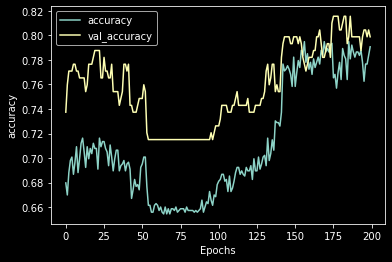

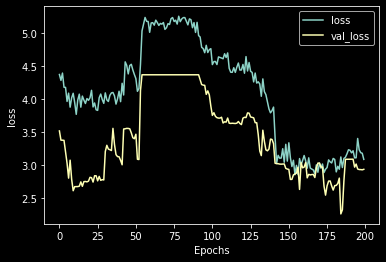

In [40]:
## this code was stolen from udacity colabs
import matplotlib.pyplot as plt
plt.style.use("dark_background")

def plot_graphs(history, string):
  plt.plot(history.history[string])
  plt.plot(history.history['val_'+string])
  plt.xlabel("Epochs")
  plt.ylabel(string)
  plt.legend([string, 'val_'+string])
  plt.show()
  
plot_graphs(history, "accuracy")
plot_graphs(history, "loss")

In [41]:
len(test_data)

418

In [42]:
test_data

,Sex,Age,SibSp,Parch,Pclass_1,Pclass_2,Pclass_3
0,1,0.452723,0.0,0.0,0,0,1
1,0,0.617566,1.0,0.0,0,0,1
2,1,0.815377,0.0,0.0,0,1,0
3,1,0.353818,0.0,0.0,0,0,1
4,0,0.287881,1.0,1.0,0,0,1
...,...,...,...,...,...,...,...
413,1,0.396975,0.0,0.0,0,0,1
414,0,0.512066,0.0,0.0,1,0,0
415,1,0.505473,0.0,0.0,0,0,1
416,1,0.396975,0.0,0.0,0,0,1


In [43]:
passenger_id=test_passenger_id.copy()
evaluation=passenger_id.to_frame()
evaluation["Survived"]=[int(bool(i)) for i in op_model.predict(test_data)]
evaluation[:10]

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0


In [44]:
evaluation.to_csv("evaluation_submission.csv",index=False)

In [45]:
answers = pd.read_csv(r"../input/titanic/gender_submission.csv")

In [46]:
from sklearn.metrics import confusion_matrix
c = confusion_matrix(answers['Survived'], evaluation['Survived'], normalize = 'true')

In [47]:
c

array([[0.97368421, 0.02631579],
       [0.01315789, 0.98684211]])